# Global Summary of the Day

### Bu projedə Global Summary of the Day (GSOD) — NOAA (ABŞ Milli Okean və Atmosfer Administrasiyası) tərəfindən toplanan günlük hava müşahidələri analiz edəcəyik.

### Üzərində analiz aparılan dataset konkret bir meteoroloji stansiyanın (hava limanı və ya rəsmi müşahidə məntəqəsi) bütün mövcud günlərini əhatə edir.

| Sütun adı             | Qısa izah                                                                                                           |
| --------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **STATION**           | Hava stansiyasının unikal ID-si (məsələn WMO və ya WBAN kodlarının birləşməsi).                                     |
| **NAME**              | Stansiyanın adı (hava limanı adı).                                                                      |
| **DATE**              | Ölçüm tarixi, `YYYY-MM-DD` formatında.                                                                              |
| **LATITUDE**          | Stansiyanın coğrafi enliyi (dərəcə).                                                                                |
| **LONGITUDE**         | Stansiyanın coğrafi uzunluğu (dərəcə).                                                                              |
| **ELEVATION**         | Stansiyanın dəniz səviyyəsindən hündürlüyü (metr).                                                                  |
| **TEMP**              | Günlük orta hava temperaturu (°C).                                                                                  |
| **TEMP\_ATTRIBUTES**  | Temperatur məlumatının keyfiyyət göstəricisi / neçə müşahidənin ortalaması olduğunu bildirən kod.                   |
| **DEWP**              | Günlük orta çiy nöqtəsi (°C).                                                                                       |
| **DEWP\_ATTRIBUTES**  | Çiy nöqtəsinin keyfiyyət kodu.                                                                                      |
| **SLP**               | Günlük orta dəniz səviyyəsi təzyiqi (hPa).                                                                          |
| **SLP\_ATTRIBUTES**   | Təzyiq məlumatının keyfiyyət kodu.                                                                                  |
| **STP**               | Günlük orta stansiya səviyyəsi təzyiqi (hPa).                                                                       |
| **STP\_ATTRIBUTES**   | Stansiya təzyiqi keyfiyyət kodu.                                                                                    |
| **VISIB**             | Günlük orta üfüqi görünürlük (km).                                                                                  |
| **VISIB\_ATTRIBUTES** | Görünürlük məlumatının keyfiyyət kodu.                                                                              |
| **WDSP**              | Günlük orta külək sürəti (m/s və ya knots – faylda qeyd edilir).                                                    |
| **WDSP\_ATTRIBUTES**  | Külək sürəti keyfiyyət kodu.                                                                                        |
| **MAX**               | Günlük maksimum temperatur (°C).                                                                                    |
| **MAX\_ATTRIBUTES**   | Maksimum temperatur ölçümünün keyfiyyət kodu.                                                                       |
| **MIN**               | Günlük minimum temperatur (°C).                                                                                     |
| **MIN\_ATTRIBUTES**   | Minimum temperatur ölçümünün keyfiyyət kodu.                                                                        |
| **PRCP**              | Günlük yağıntı miqdarı (mm).                                                                                        |
| **PRCP\_ATTRIBUTES**  | Yağıntı keyfiyyət və ya “trace amount” (çox az) kimi işarə edən kod.                                                |
| **SNDP**              | Günlük qar örtüyü dərinliyi (mm).                                                                                   |
| **SNDP\_ATTRIBUTES**  | Qar məlumatının keyfiyyət kodu.                                                                                     |
| **FRSHTT**            | Altı rəqəmli kod: Gün ərzində hadisələrin olub-olmaması (Duman, Yağış, Qar, Dolu, Tornado, İldırım). Hər mövqe 0/1. |


# Analiz edəcəyimiz istiqamətlər:

İqlim trendləri

* Aylar üzrə orta temperatur artımı və ya azalması

* Mövsümlər üzrə fərqlər (yay/qış temperatur müqayisəsi)

Ekstrem hadisələr

* Rekord minimum və maksimum temperatur

* Gündəlik yağıntı pikləri, qar dərinliyi

Paylanma və dəyişkənlik

* Temperaturun və ya külək sürətinin histogramı

* Ay üzrə yağıntı miqdarının boxplot-u

Korelasiya

* Temperatur və təzyiq arasında əlaqə

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv(r'C:\Users\User\Desktop\Data\Projects\Global Summary of the Day Analysis\dataset\Global Summary of the Day.csv')

data

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,TEMP,TEMP_ATTRIBUTES,DEWP,DEWP_ATTRIBUTES,...,MXSPD,GUST,MAX,MAX_ATTRIBUTES,MIN,MIN_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNDP,FRSHTT
0,1001099999,2025-01-01,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",17.4,8,10.3,8,...,27.2,39.4,24.4,,9.7,,0.05,G,999.9,1000
1,1001099999,2025-01-02,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",12.0,9,6.5,9,...,29.1,48.6,16.9,,8.2,,0.02,G,999.9,0
2,1001099999,2025-01-03,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",20.7,8,15.4,8,...,30.9,43.9,23.9,,15.1,,0.02,G,999.9,1000
3,1001099999,2025-01-04,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",22.1,8,15.8,8,...,24.5,35.4,23.9,,19.8,,0.00,G,999.9,1000
4,1001099999,2025-01-05,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",26.5,8,22.6,8,...,28.9,39.4,30.9,,19.6,,0.00,G,999.9,11000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,1001099999,2025-08-20,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",43.9,8,38.5,8,...,25.3,999.9,47.3,,40.8,,0.00,G,999.9,0
232,1001099999,2025-08-21,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",43.7,8,36.0,8,...,23.1,30.5,48.6,,39.0,,0.01,G,999.9,0
233,1001099999,2025-08-22,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",45.5,8,36.8,8,...,9.7,19.4,49.3,,42.1,,0.01,G,999.9,0
234,1001099999,2025-08-23,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",45.9,8,40.7,8,...,11.7,13.6,49.6,,41.9,,0.00,G,999.9,0


In [7]:
df = data.copy()

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
STATION,236.0,1.001100e+09,0.000000e+00,1.001100e+09,1.001100e+09,1.001100e+09,1.001100e+09,1.001100e+09
LATITUDE,236.0,7.093333e+01,1.566516e-13,7.093333e+01,7.093333e+01,7.093333e+01,7.093333e+01,7.093333e+01
LONGITUDE,236.0,-8.666667e+00,3.560265e-14,-8.666667e+00,-8.666667e+00,-8.666667e+00,-8.666667e+00,-8.666667e+00
ELEVATION,236.0,9.000000e+00,0.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00
TEMP,236.0,3.424237e+01,9.130714e+00,1.180000e+01,2.787500e+01,3.385000e+01,4.152500e+01,5.250000e+01
TEMP_ATTRIBUTES,236.0,1.204237e+01,5.092162e+00,4.000000e+00,8.000000e+00,9.000000e+00,1.700000e+01,2.400000e+01
DEWP,236.0,3.048686e+01,1.065475e+01,2.400000e+00,2.225000e+01,3.015000e+01,3.832500e+01,5.060000e+01
DEWP_ATTRIBUTES,236.0,1.204237e+01,5.092162e+00,4.000000e+00,8.000000e+00,9.000000e+00,1.700000e+01,2.400000e+01
SLP,236.0,1.008678e+03,1.351042e+01,9.672000e+02,1.001225e+03,1.010250e+03,1.016450e+03,1.046300e+03
SLP_ATTRIBUTES,236.0,1.204237e+01,5.092162e+00,4.000000e+00,8.000000e+00,9.000000e+00,1.700000e+01,2.400000e+01


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   STATION           236 non-null    int64  
 1   DATE              236 non-null    object 
 2   LATITUDE          236 non-null    float64
 3   LONGITUDE         236 non-null    float64
 4   ELEVATION         236 non-null    float64
 5   NAME              236 non-null    object 
 6   TEMP              236 non-null    float64
 7   TEMP_ATTRIBUTES   236 non-null    int64  
 8   DEWP              236 non-null    float64
 9   DEWP_ATTRIBUTES   236 non-null    int64  
 10  SLP               236 non-null    float64
 11  SLP_ATTRIBUTES    236 non-null    int64  
 12  STP               236 non-null    float64
 13  STP_ATTRIBUTES    236 non-null    int64  
 14  VISIB             236 non-null    float64
 15  VISIB_ATTRIBUTES  236 non-null    int64  
 16  WDSP              236 non-null    float64
 1

In [15]:
df.shape

(236, 28)

In [17]:
df.dtypes

STATION               int64
DATE                 object
LATITUDE            float64
LONGITUDE           float64
ELEVATION           float64
NAME                 object
TEMP                float64
TEMP_ATTRIBUTES       int64
DEWP                float64
DEWP_ATTRIBUTES       int64
SLP                 float64
SLP_ATTRIBUTES        int64
STP                 float64
STP_ATTRIBUTES        int64
VISIB               float64
VISIB_ATTRIBUTES      int64
WDSP                float64
WDSP_ATTRIBUTES       int64
MXSPD               float64
GUST                float64
MAX                 float64
MAX_ATTRIBUTES       object
MIN                 float64
MIN_ATTRIBUTES       object
PRCP                float64
PRCP_ATTRIBUTES      object
SNDP                float64
FRSHTT                int64
dtype: object

In [25]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [27]:
df.isnull().sum()

STATION             0
DATE                0
LATITUDE            0
LONGITUDE           0
ELEVATION           0
NAME                0
TEMP                0
TEMP_ATTRIBUTES     0
DEWP                0
DEWP_ATTRIBUTES     0
SLP                 0
SLP_ATTRIBUTES      0
STP                 0
STP_ATTRIBUTES      0
VISIB               0
VISIB_ATTRIBUTES    0
WDSP                0
WDSP_ATTRIBUTES     0
MXSPD               0
GUST                0
MAX                 0
MAX_ATTRIBUTES      0
MIN                 0
MIN_ATTRIBUTES      0
PRCP                0
PRCP_ATTRIBUTES     0
SNDP                0
FRSHTT              0
dtype: int64

In [29]:
df['TEMP_ATTRIBUTES'].unique()

array([ 8,  9,  7, 10,  4,  6,  5, 13, 24, 17, 20, 21, 14, 19, 23, 22, 15,
       16, 18, 12, 11])

In [31]:
df_sorted = df.sort_values(by='TEMP', ascending=True)

df_sorted[['TEMP', 'TEMP_ATTRIBUTES']]

,TEMP,TEMP_ATTRIBUTES
9,11.8,9
1,12.0,9
10,12.7,8
18,14.9,8
73,15.6,8
...,...,...
219,49.5,8
206,49.8,8
204,50.3,8
207,51.5,8


# 2025-ci ilin ilk 8 ayı üzrə orta temperatur artımı və ya azalması

In [34]:
# Year sütunu yaradırıq
df['Month'] = df['DATE'].dt.month

In [83]:
pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [84]:
import pandas as pd
import duckdb

# DuckDB ilə SQL sorğuları
con = duckdb.connect()
new_df = con.execute(""" SELECT
    AVG(TEMP) as avg_temp, 
    Month
    FROM df
    GROUP BY Month
    ORDER BY Month
    """).fetchdf()

new_df

,avg_temp,Month
0,25.203226,1
1,30.046429,2
2,24.958065,3
3,28.943333,4
4,35.309677,5
5,39.306667,6
6,46.203226,7
7,46.270833,8


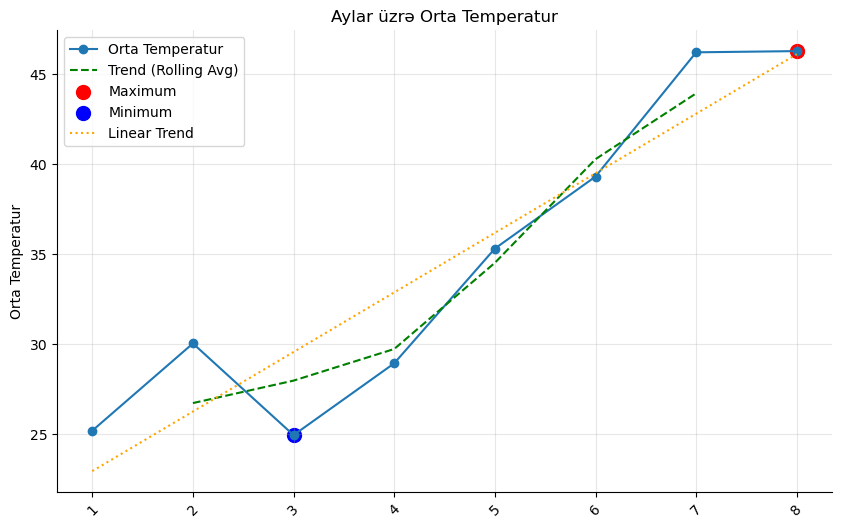

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Rolling average
new_df['RollingAvg'] = new_df['avg_temp'].rolling(3, center=True).mean()

plt.figure(figsize=(10,6))
plt.plot(new_df['Month'], new_df['avg_temp'], 'o-', label='Orta Temperatur')
plt.plot(new_df['Month'], new_df['RollingAvg'], '--', color='green', label='Trend (Rolling Avg)')

# Maksimum və minimum
plt.scatter(new_df['Month'][new_df['avg_temp'].idxmax()], new_df['avg_temp'].max(), color='red', s=100, label='Maximum')
plt.scatter(new_df['Month'][new_df['avg_temp'].idxmin()], new_df['avg_temp'].min(), color='blue', s=100, label='Minimum')

# Linear trend
z = np.polyfit(range(len(new_df)), new_df['avg_temp'], 1)
plt.plot(new_df['Month'], np.poly1d(z)(range(len(new_df))), ':', color='orange', label='Linear Trend')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.title('Aylar üzrə Orta Temperatur')
plt.ylabel('Orta Temperatur')
plt.legend()

sns.despine()
plt.show()

### Bu qrafikdə il ərzində aylara görə orta temperaturu görürük. Məqsədimiz ilin hansı aylarında temperaturun yüksəldiyini və düşdüyünü görməkdir. 

### Min temperatur Yanvar və Mart aylarında, Max temperatur isə Avqust ayında müşahidə olunmuşdur.

### Fevral ayında bir az yüksək orta temperatur müşahidə olunur, bu isə qeyri-adi hava şəraitindən qaynaqlana bilər.
### Mart ayından sonra havalarda temperatur artması müşahidə olunmuşdur.

### Bu məlumat şəhər planlaması və kənd təsərrüfatı üçün faydalıdır, çünki məhsulların əkilməsi və yığımı üçün ideal dövrü göstərir.

# Aylar üzrə ortalama yağış, qar miqdarı
## İlin ən çox yağıntı olan günləri

In [91]:
# Aylar üzrə ortalama yağış və qar miqdarı

con = duckdb.connect()
new_df2 = con.execute(""" SELECT
    AVG(PRCP) as avg_yagis, 
    AVG(SNDP) as avg_qar,
    Month
    FROM df
    GROUP BY Month
    ORDER BY Month
    """).fetchdf()

new_df2

,avg_yagis,avg_qar,Month
0,6.487419,999.9,1
1,3.650357,999.9,2
2,3.260000,999.9,3
3,0.029000,999.9,4
4,0.010645,999.9,5
5,0.050333,999.9,6
6,0.025806,999.9,7
7,0.084167,999.9,8


In [93]:
import duckdb

con = duckdb.connect()

new_df2 = con.execute("""
    SELECT DATE, avg_yagis
    FROM (
        SELECT DATE, AVG(PRCP) AS avg_yagis
        FROM df
        GROUP BY DATE
    ) AS t
    WHERE avg_yagis = (SELECT MAX(avg_yagis) FROM (
                           SELECT AVG(PRCP) AS avg_yagis
                           FROM df
                           GROUP BY DATE
                       ) )
""").fetchdf()

new_df2


,DATE,avg_yagis
0,2025-03-26,99.99
1,2025-01-23,99.99
2,2025-02-14,99.99
3,2025-01-22,99.99


# Temperaturun paylanması

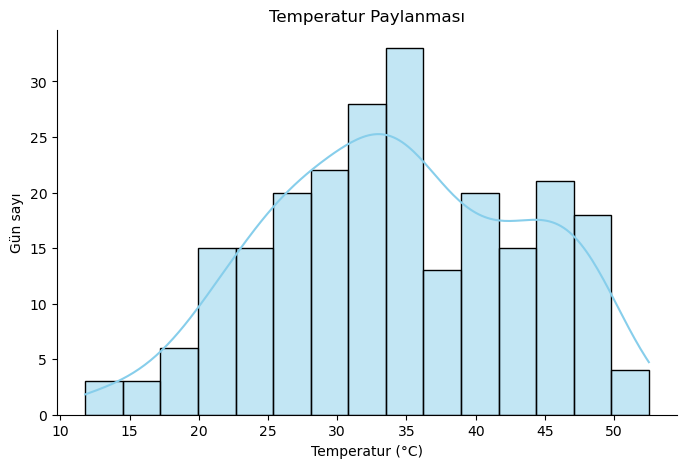

In [96]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['TEMP'], bins=15, kde=True, color='skyblue')
plt.title('Temperatur Paylanması')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Gün sayı')

sns.despine()
plt.show()

In [48]:
!pip install scipy

In [58]:
import sys
print(sys.executable)

C:\Users\User\anaconda3\envs\myenv\python.exe


In [60]:
!{sys.executable} -m pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 2.6 MB/s eta 0:00:14
   -- ------------------------------------- 2.1/36.5 MB 4.5 MB/s eta 0:00:08
   --- ------------------------------------ 3.1/36.5 MB 4.6 MB/s eta 0:00:08
   ---- ----------------------------------- 3.9/36.5 MB 4.5 MB/s eta 0:00:08
   ----- ---------------------------------- 5.0/36.5 MB 4.7 MB/s eta 0:00:07
   ------ --------------------------------- 6.0/36.5 MB 4.6 MB/s eta 0:00:07
   ------- -------------------------------- 7.1/36.5 MB 4.6 MB/s eta 0:00:07
   -------- ------------------------------- 8.1/36.5 MB 4.8 MB/s eta 0:00:06
   ---------- ----------------------------- 9.4/36.5 MB 4.9 MB/s eta 0:00:06
   ----------- ---------------------------- 10.5/36.5 MB 4.8 MB/s eta 0:00:06
   ----------- ---------------------------- 10.5/36.5 MB 4.8 MB/s eta 0:00:06
   --------

In [62]:
import pandas as pd
from scipy.stats import skew

temperatur = [10, 15, 20, 25, 30, 32, 35, 36, 40, 45, 50]

# Skewness hesablayaq
skewness = skew(temperatur)
print("Skewness:", skewness)

Skewness: -0.17261700532873217


### Skewness:

#### Müsbət ( > 0 ) → (Right Skew)

#### Mənfi ( < 0 ) → (Left Skew)

#### 0-a yaxın → demək olar simmetrik (Normal)

#### -0.17 çox kiçik dəyərdir → bu o idarə ki, zəif Left Skew, amma faktiki olaraq demək olar simmetrikdir

# Ay üzrə yağıntı miqdarının boxplot-u

In [69]:
df['PRCP'].describe()

count    236.000000
mean       1.736907
std       12.928964
min        0.000000
25%        0.000000
50%        0.010000
75%        0.050000
max       99.990000
Name: PRCP, dtype: float64

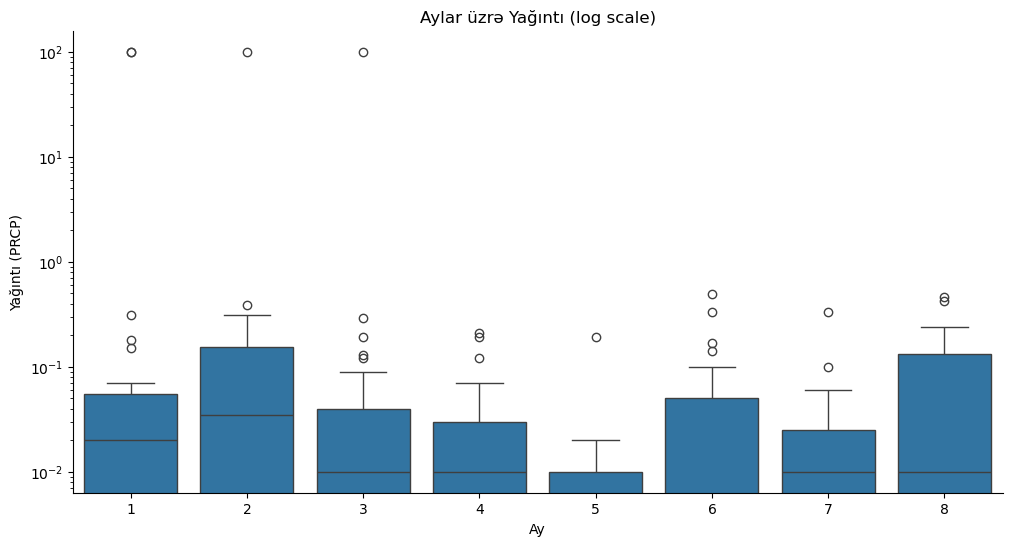

In [77]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Month', y='PRCP', data=df)
plt.yscale('log')  # log scale ilə kiçik və böyük dəyərlər görünəcək
plt.title("Aylar üzrə Yağıntı (log scale)")
plt.xlabel("Ay")
plt.ylabel("Yağıntı (PRCP)")

sns.despine()
plt.show()

#### Yağıntı az hallarda baş verir, amma bəzən çox güclü olur
#### Aylar arasında fərq var, amma hamısında skewness yüksəkdir

In [103]:
df['PRCP']

0      0.05
1      0.02
2      0.02
3      0.00
4      0.00
       ... 
231    0.00
232    0.01
233    0.01
234    0.00
235    0.00
Name: PRCP, Length: 236, dtype: float64

In [105]:
# Skewness hesablayaq
skewness = skew(df['PRCP'])
print("Skewness:", skewness)

Skewness: 7.483963952566781


#### Yağıntı məlumatları əsasən sağa meylli paylanmaya malikdir. 
#### Əksər günlərdə yağıntı az olur, lakin bəzi günlərdə yüksək dəyərlər müşahidə edilir. 
#### Bəzi aylarda dəyişkənlik daha yüksəkdir, bu da hava şəraitinin qeyri-sabit olduğunu göstərir.

# Temperatur və təzyiq arasında əlaqə

In [178]:
# TEMP və STP arasındakı korrelyasiya
correlation = df['TEMP'].corr(df['STP'])

print("TEMP və STP arasındakı korrelyasiya:", correlation)


TEMP və STP arasındakı korrelyasiya: 0.1216088680801207


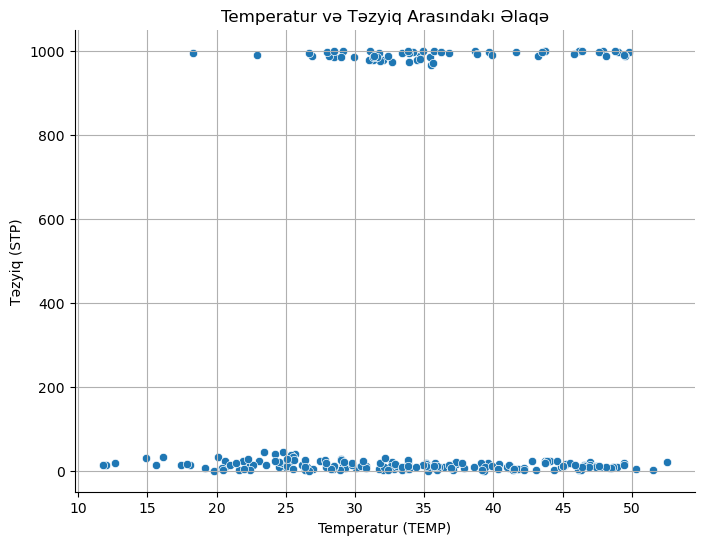

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='TEMP', y='STP', data=df)
plt.title("Temperatur və Təzyiq Arasındakı Əlaqə")
plt.xlabel("Temperatur (TEMP)")
plt.ylabel("Təzyiq (STP)")
plt.grid(True)

sns.despine()
plt.show()

#### Əlaqə çox zəifdir

#### Müsbət olsa da, demək olar ki, əhəmiyyətli bir lineer əlaqə yoxdur

#### Yəni temperatur artdıqca təzyiqdə yalnız çox kiçik bir artım müşahidə olunur, amma bu praktiki olaraq önəmli deyil